In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Анализ временного ряда

In [28]:
df = pd.read_csv(r"C:\Users\Tysyachnyj V\Desktop\Предиктивная аналитика\retail_sales_mock_data.csv", parse_dates=True, index_col="Date")
df.head()

,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>], dtype=object)

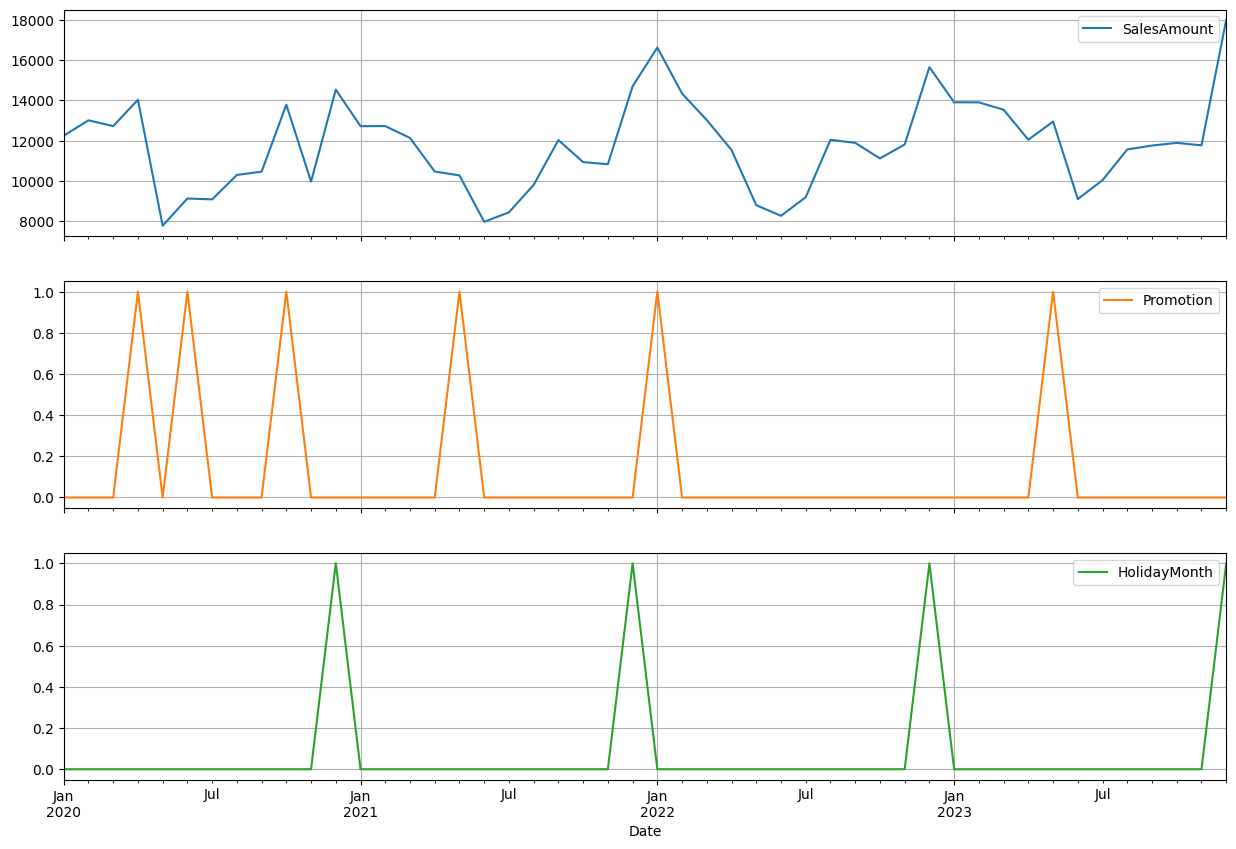

In [29]:
df.plot(subplots=True, figsize=(15,10), grid=True)

Text(0.5, 1.0, 'Ящики с усами по годам')

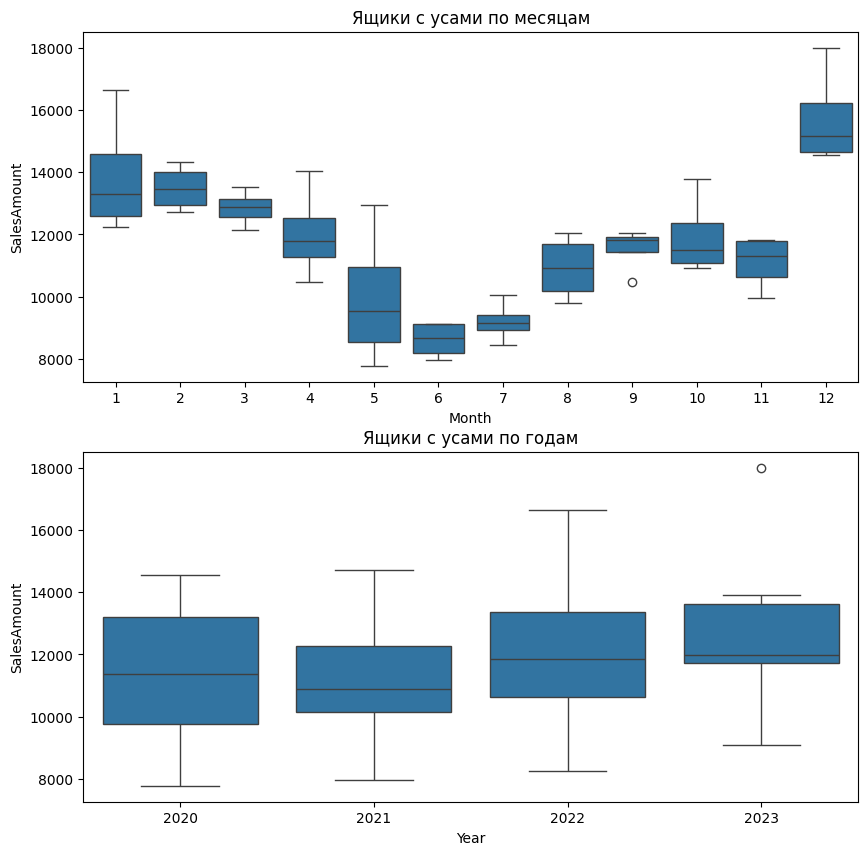

In [30]:
df['Month'] = df.index.month
df['Year'] = df.index.year
fig, axes = plt.subplots(2, 1, figsize=(10, 10))
sns.boxplot(df, x='Month', y="SalesAmount", ax=axes[0])
axes[0].set_title("Ящики с усами по месяцам")
sns.boxplot(df, x='Year', y="SalesAmount", ax=axes[1])
axes[1].set_title("Ящики с усами по годам")

Данные представляют собой выручку по месяцам с 2020 по 2023 год с отметками о проведении акций и праздничном месяце, которым является декабрь (в связи с праздниками и окончанием года продажи выше).

Судя по построенным боксплотам, в данных присутвует сезонный тренд (летом просадка, а зимой значительный рост). Также по годовому графике можно сказать, что в среднем доходность за год повышается, но не так так сильно, если смотреть медиану, но при этом крайние значения по годам показывают стабильный рост.

В некоторые месяца наблюдается сильно больший разброс значений, что, наверное, можно объяснить небольшой выборкой (в 4 года) и разными экономическими нестабильными факторами.

In [31]:
import calendar

df['Усреденные_доходы'] = df['SalesAmount'].rolling(window=3).mean()

all_month_year_df = pd.pivot_table(df, values="SalesAmount",
                                   index=["Month"],
                                   columns=["Year"],
                                   fill_value=0)

month_index = [month for month in calendar.month_abbr if month]

all_month_year_df = all_month_year_df.set_index([month_index])

all_month_year_df

Year,2020,2021,2022,2023
Jan,12248.0,12720.0,16623.0,13904.0
Feb,13011.0,12724.0,14336.0,13901.0
Mar,12722.0,12136.0,13023.0,13534.0
Apr,14030.0,10468.0,11537.0,12048.0
May,7783.0,10279.0,8800.0,12949.0
Jun,9131.0,7976.0,8273.0,9104.0
Jul,9089.0,8445.0,9199.0,10042.0
Aug,10300.0,9810.0,12043.0,11566.0
Sep,10464.0,12031.0,11892.0,11759.0
Oct,13786.0,10937.0,11121.0,11890.0


Text(0.5, 1.0, 'Sales amount')

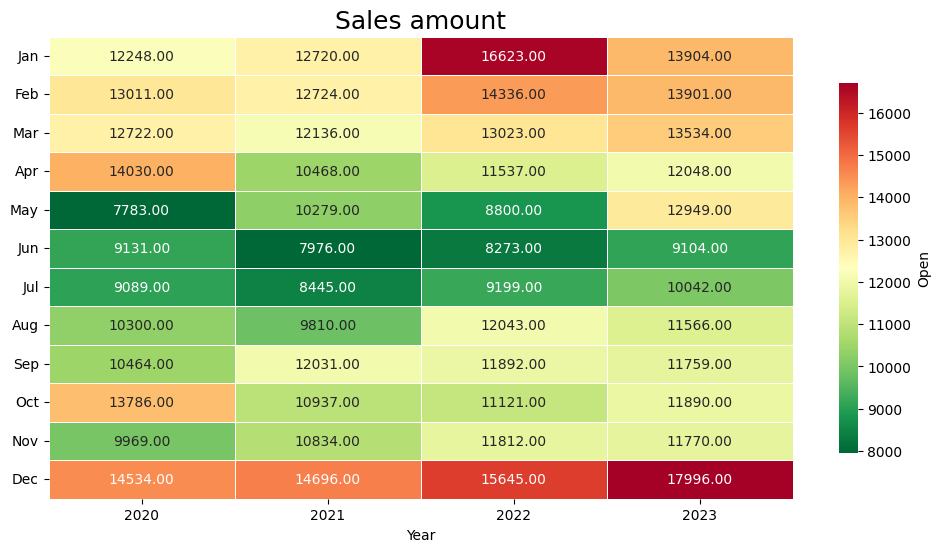

In [32]:
fig, ax = plt.subplots(figsize=(12,6))
ax = sns.heatmap(all_month_year_df, cmap='RdYlGn_r', robust=True,
                 fmt='.2f', annot=True, linewidths=.5, ax=ax,
                 cbar_kws={'shrink':.8, 'label':'Open'})

ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.title('Sales amount', fontdict={'fontsize':18})

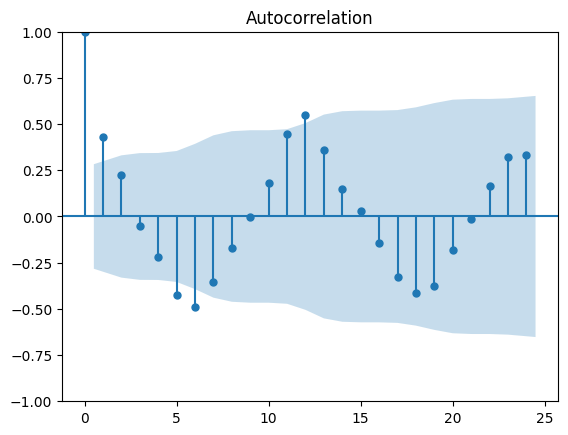

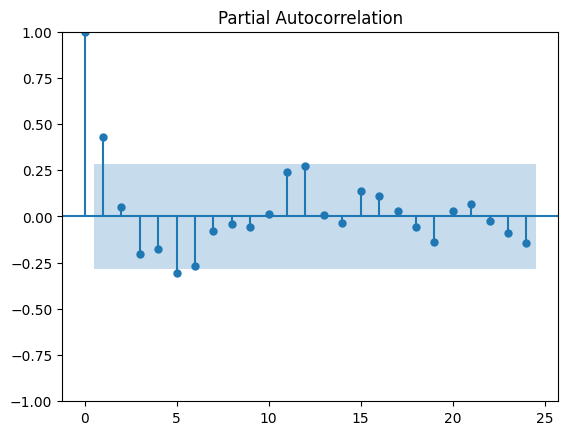

In [33]:
# для сравнения график ACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig1 = plot_acf(df['SalesAmount'], lags=24)
fig2 = plot_pacf(df['SalesAmount'], lags=24)
plt.show()

Графики автокорреляций подтверждают наличие сезонного тренда: график достаточно плавно синусоидально затихает, при этом есть положительная корреляция на годовых циклах, и отрицательная на полугодовых. Также график частичной автокорреляции показывает, что наибольшее влияние имеет только предыдущий месяц и тот, что был 5 месяцев назад, остальные уже не выходят за пределы доверительного интеравала.

In [34]:
from statsmodels.tsa.stattools import adfuller, kpss

dftest = adfuller(df['SalesAmount'], autolag="AIC")
print(f"Тест Дики-Фуллера: {dftest[1]}")

kpsstest = kpss(df['SalesAmount'], regression="c", nlags="auto")
print(f"KPSS-тест: {kpsstest[1]}")

Тест Дики-Фуллера: 0.0001853558643026136
KPSS-тест: 0.1


C:\Users\Tysyachnyj V\AppData\Local\Temp\ipykernel_18708\3237079104.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  dftest = adfuller(df['SalesAmount'], autolag="AIC")
C:\Users\Tysyachnyj V\AppData\Local\Temp\ipykernel_18708\3237079104.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpsstest = kpss(df['SalesAmount'], regression="c", nlags="auto")
C:\Users\Tysyachnyj V\AppData\Local\Temp\ipykernel_18708\3237079104.py:6: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `l

Тесты Дики-Фуллера и KPSS дали соглассованный результат: в первом тесте нулевая гипотеза (нестационарность) не принимается, а во втором (стационарность) - принимается. 

Таким образом, можно сделать вывод, что данный ряд стационарен, но имееет достаточно сильную сезонность.

# Аддитивная декомпозиция

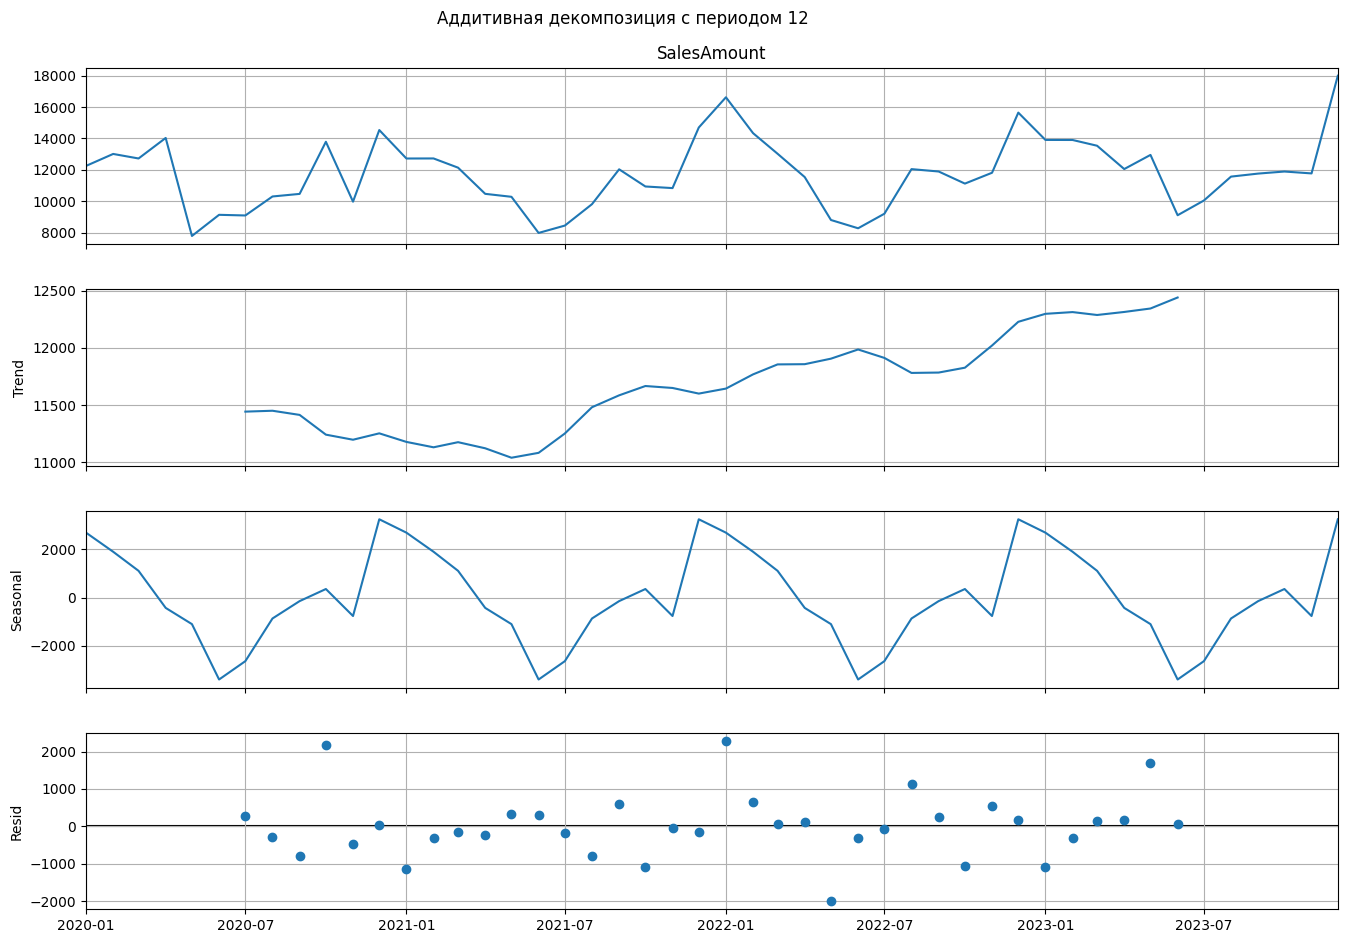

In [35]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['SalesAmount'], model='additive', period=12)

fig = result.plot()

for ax in fig.axes:
    ax.figure.set_size_inches(15, 10)
    ax.grid()

plt.suptitle("Аддитивная декомпозиция с периодом 12")
plt.show()

# Мультипликативная декомпозиция

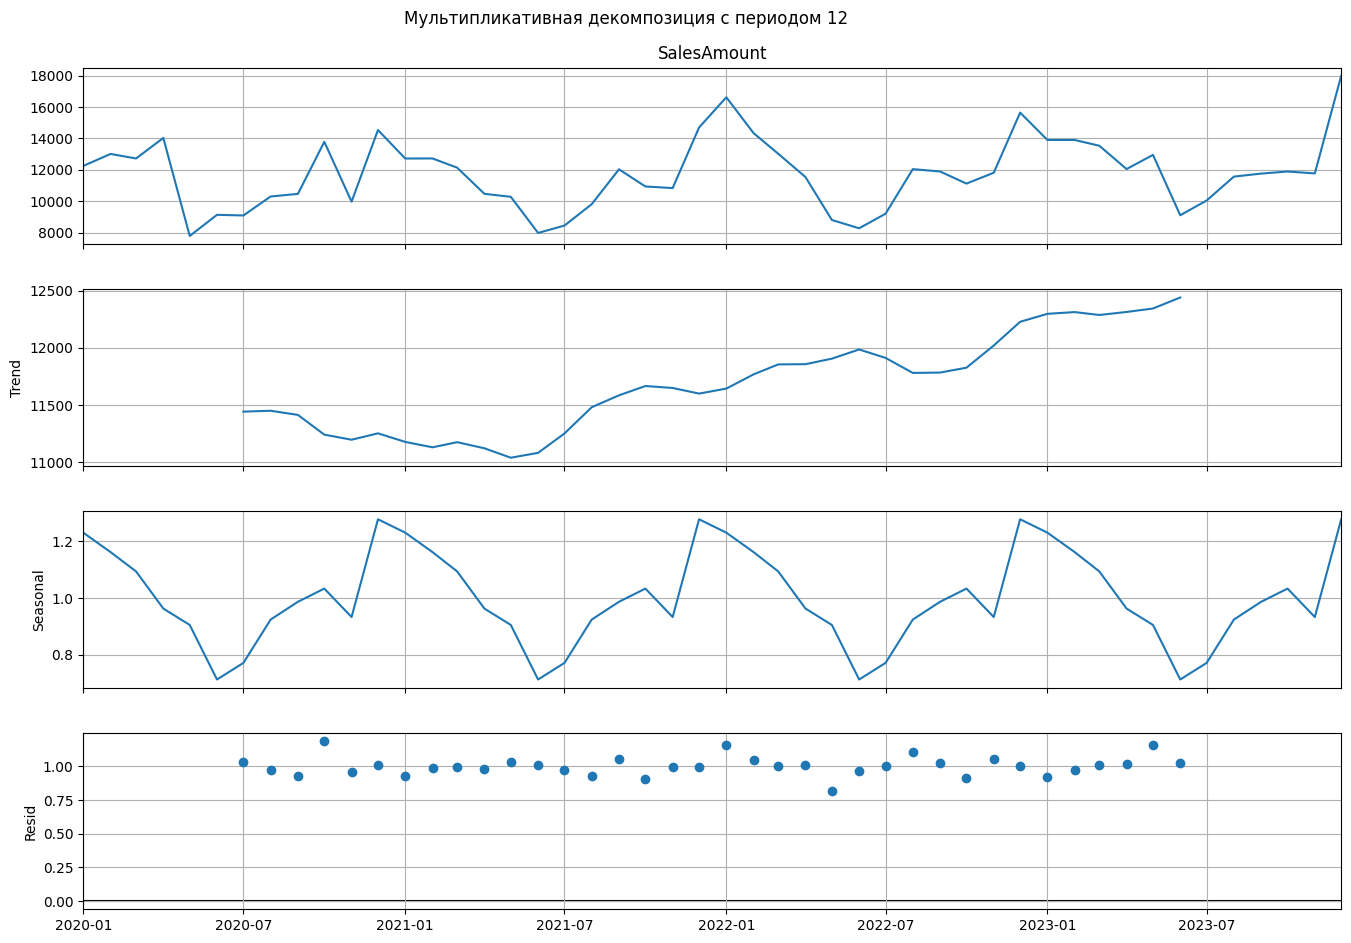

In [36]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['SalesAmount'], model='multiplicative', period=12)

fig = result.plot()

for ax in fig.axes:
    ax.figure.set_size_inches(15, 10)
    ax.grid()

plt.suptitle("Мультипликативная декомпозиция с периодом 12")
plt.show()

# STL декомпозиция

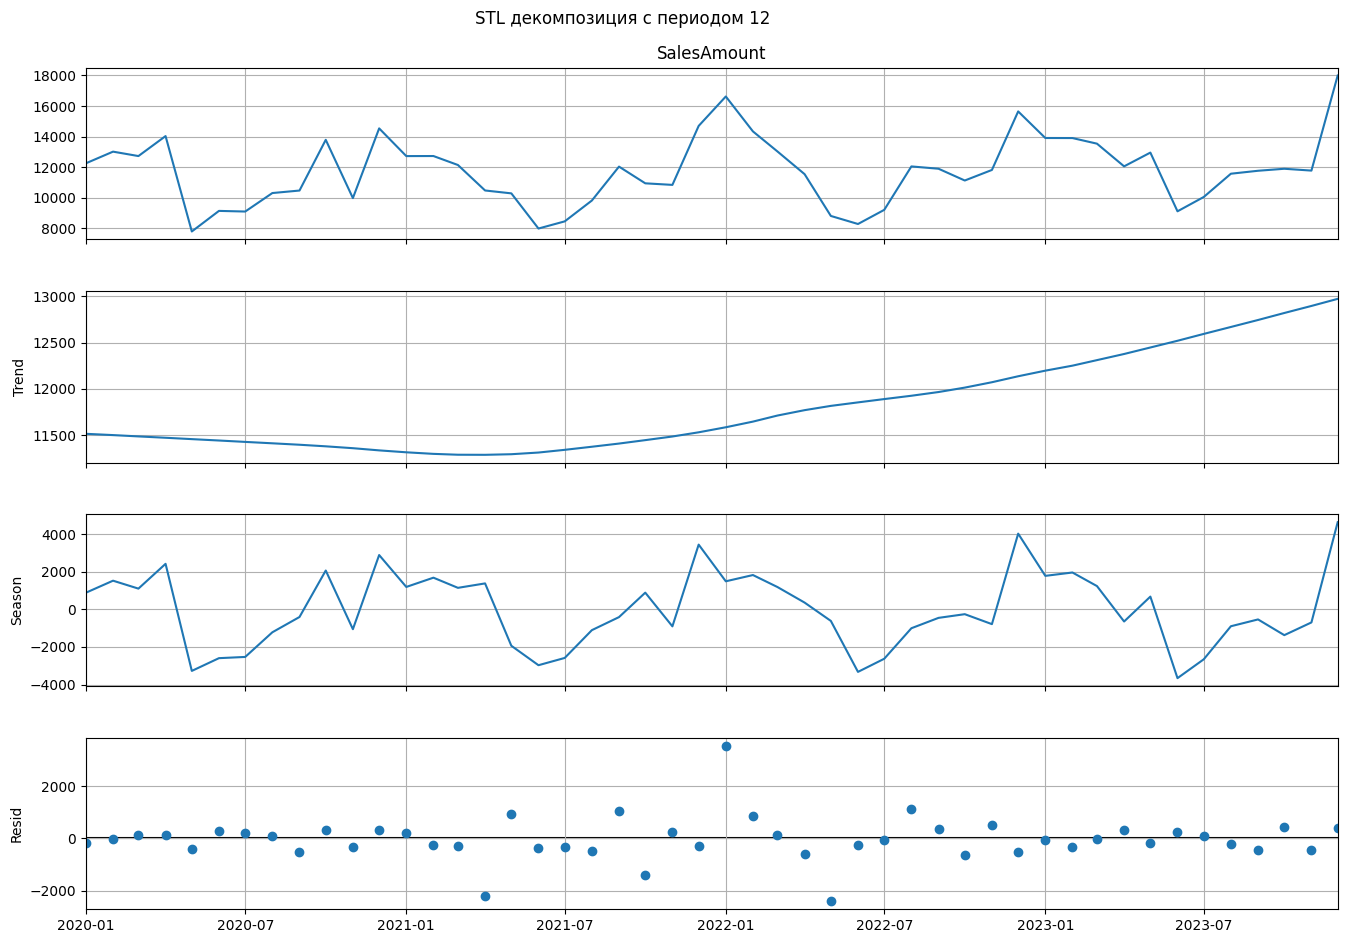

In [37]:
from statsmodels.tsa.seasonal import STL

stl = STL(df['SalesAmount'], period=12, seasonal=13, robust=True)
result = stl.fit()

fig = result.plot()

for ax in fig.axes:
    ax.figure.set_size_inches(15, 10)
    ax.grid()

plt.suptitle("STL декомпозиция с периодом 12")
plt.show()

# Спектральный анализ

In [ ]:
from scipy.fft import fft, fftfreq

dt = 1
n = len(df['SalesAmount'])

# FFT
fft_vals = fft(df['SalesAmount'])
freqs = fftfreq(n, dt)

# Берём только положительные частоты
power = np.abs(fft_vals[:n//2])
freqs_pos = freqs[:n//2]

# Переводим частоту в период (дни)
periods = 1 / freqs_pos[1:]
power_pos = power[1:]

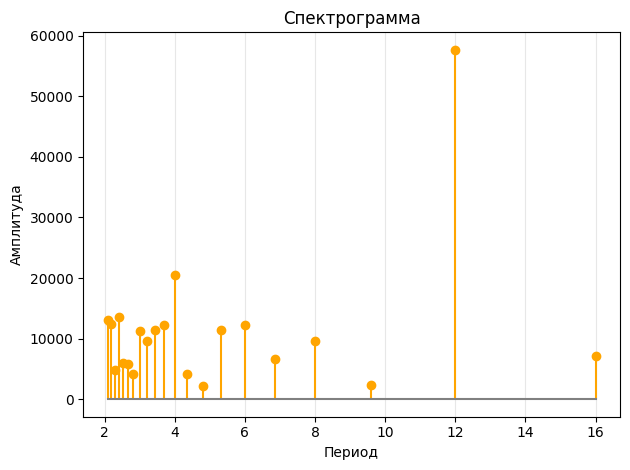

In [50]:
mask = (periods >= 2) & (periods <= 16)
plt.stem(periods[mask], power_pos[mask], linefmt='orange', markerfmt='o', basefmt='gray')
plt.xlabel('Период')
plt.ylabel('Амплитуда')
plt.title('Спектрограмма')
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Вейвлет анализ

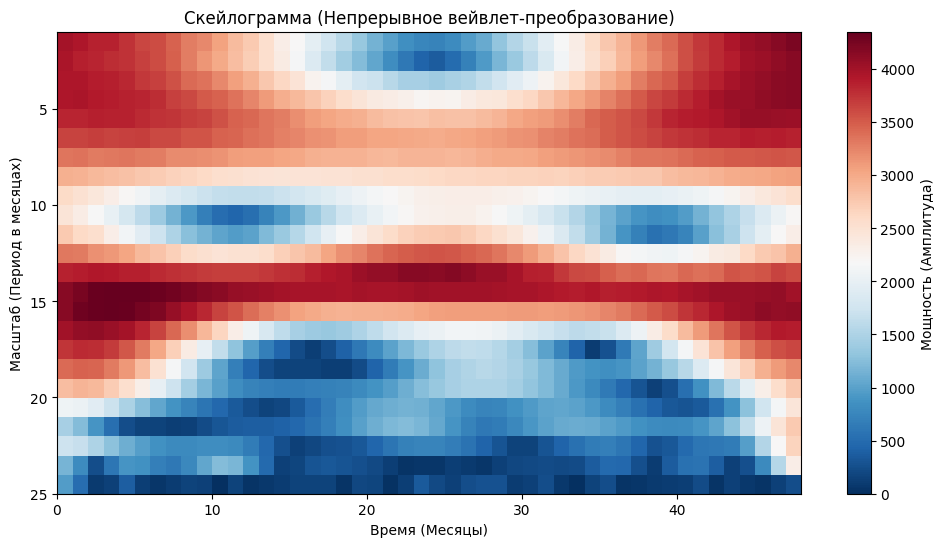

In [52]:
import pywt

# 1. Определяем масштабы (scales). 
# Так как у нас 48 месяцев и период сезонности = 12, 
# масштабы от 1 до 32 покрывают короткие и годовые циклы.
scales = np.arange(1, 25)

coefficients, frequencies = pywt.cwt(df['SalesAmount'], scales, 'cmor1.5-1.0', sampling_period=1)

# 3. Строим скейлограмму
plt.figure(figsize=(12, 6))
# Берем модуль коэффициентов для отображения мощности
plt.imshow(np.abs(coefficients), extent=[0, len(df['SalesAmount']), 1, 25], 
           cmap='RdBu_r', aspect='auto', vmax=abs(coefficients).max(), vmin=0)

plt.colorbar(label='Мощность (Амплитуда)')
plt.ylabel('Масштаб (Период в месяцах)')
plt.xlabel('Время (Месяцы)')
plt.title('Скейлограмма (Непрерывное вейвлет-преобразование)')
plt.gca().invert_yaxis() # Инвертируем ось Y, чтобы большие периоды были внизу
plt.show()

Среди классических декомпозиций наиболее хороший результат показала STL декомпозиция, которая смогла выделить практически гладкий тренд. Аддитивная и мультипликативная оказались слишком простыми для таких достаточно сложных данных.

Спектральный анализ показал явно годовой тренд и, что интересно, квартальный тренд, но заметно слабее, остальные на одном уровне. Стационарность позволила четко определить доминирующие частоты даже без удаления тренда, который все-таки небольшой, но есть.

Вейвлет анализ показал наличие стабильных сезонных трендов с периодом 6 месяцев (полугодовой) и, что опять же интересно, сезонность в 13 и 14 месяцев (у 12 амплитуда слабее). Благодаря этому подходу можно проследить эволюцию периодов, но из-за малого количества данных слишком большое влияние краевого эффекта, из-за чего данные имеют искажения.

# ARIMA

Поскольку основная сезонность годовая, а имеются данные только за 4 года, то наиболее логичным будет три первых года дать на обучение, а последний на предсказание.

На графике PACF реально значимым был только 1 лаг, так что следует взять AR(1): p=1 (для эксперимента можно поставить еще 5)

Поскольку тесты показали стационарность, то дифференцирование не требуется: d=0

Судя по графику ACF можно попробовать принять MA(1): q=1

In [ ]:
train_size = 36
train = df['SalesAmount'][:train_size]
test = df['SalesAmount'][train_size:]

c:\Users\Tysyachnyj V\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Tysyachnyj V\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Tysyachnyj V\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Tysyachnyj V\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Tysyachnyj V\AppDat

                               SARIMAX Results                                
Dep. Variable:            SalesAmount   No. Observations:                   36
Model:                 ARIMA(5, 0, 1)   Log Likelihood                -316.011
Date:                Thu, 08 Oct 2026   AIC                            648.022
Time:                        23:29:41   BIC                            660.690
Sample:                    01-01-2020   HQIC                           652.444
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.151e+04    171.922     66.960      0.000    1.12e+04    1.18e+04
ar.L1          0.8416      0.297      2.838      0.005       0.260       1.423
ar.L2         -0.1776      0.312     -0.569      0.5

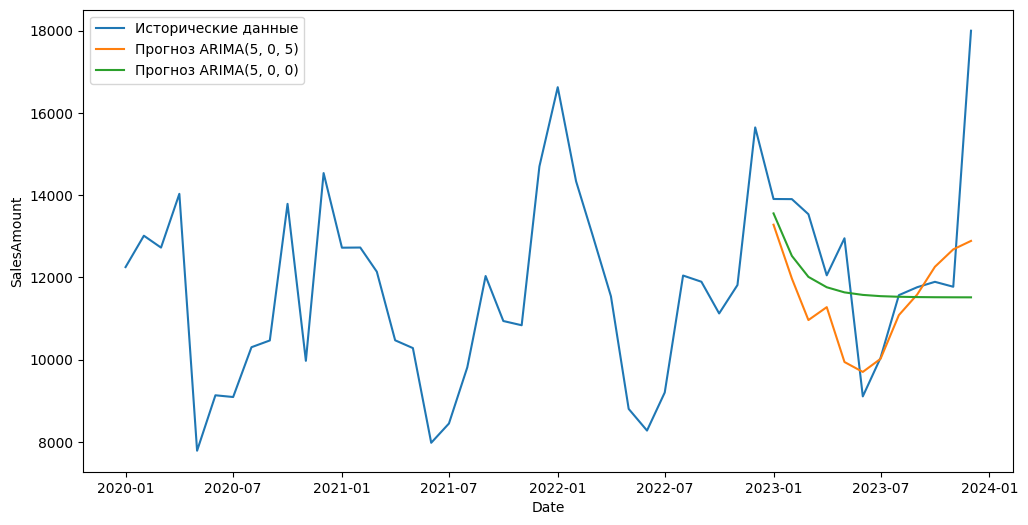

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model_arima_1 = ARIMA(train, order=(5, 0, 1)).fit()
model_arima_2 = ARIMA(train, order=(1, 0, 0)).fit()
print(model_arima_1.summary())
print(model_arima_2.summary())

# Прогноз на 12 месяца вперед
forecast_arima_1 = model_arima_1.predict(start=len(train), end=len(train)+11)
forecast_arima_2 = model_arima_2.predict(start=len(train), end=len(train)+11)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df['SalesAmount'], label='Исторические данные')
sns.lineplot(data=forecast_arima_1, label='Прогноз ARIMA(5, 0, 1)')
sns.lineplot(data=forecast_arima_2, label='Прогноз ARIMA(1, 0, 0)')

plt.show()

In [ ]:
from pmdarima import auto_arima

model = auto_arima(
    train,
    start_p=0, max_p=13,
    start_q=0, max_q=13,
    d=0,
    seasonal=False,
    trace=True,
    stepwise=True
)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=778.739, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=664.123, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=744.544, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=664.726, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=665.549, Time=0.06 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=653.040, Time=0.01 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=660.355, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=655.042, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=655.105, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=655.621, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=656.320, Time=0.05 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 0.272 seconds


# SARIMAX

Из предыдущих рассуждений понятно, что основная сезонность - годовая: s=12

Сезонные параметры соответственно: (P, D, Q, s)=(1, 0, 0, 12) (можно попробовать Q=1)

c:\Users\Tysyachnyj V\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Tysyachnyj V\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(
c:\Users\Tysyachnyj V\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
c:\Users\Tysyachnyj V\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  

                                      SARIMAX Results                                       
Dep. Variable:                          SalesAmount   No. Observations:                   36
Model:             SARIMAX(1, 0, 0)x(1, 0, [1], 12)   Log Likelihood                -327.119
Date:                              Thu, 08 Oct 2026   AIC                            662.237
Time:                                      23:51:33   BIC                            668.571
Sample:                                  01-01-2020   HQIC                           664.448
                                       - 12-01-2022                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9492      0.054     17.476      0.000       0.843       1.056
ar.S.L12       0.99

<Axes: xlabel='Date', ylabel='SalesAmount'>

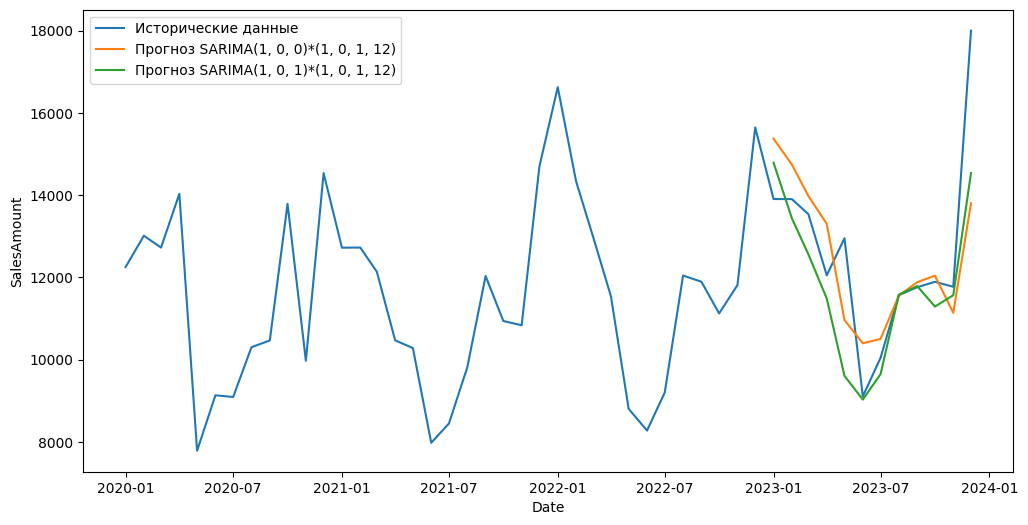

In [99]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model_1 = SARIMAX(train, 
                       order=(1, 0, 0), 
                       seasonal_order=(1, 0, 1, 12),
                       freq='MS')
sarima_result_1 = sarima_model_1.fit(disp=False)
sarima_model_2 = SARIMAX(train, 
                       order=(1, 0, 1), 
                       seasonal_order=(1, 0, 1, 12),
                       freq='MS')
sarima_result_2 = sarima_model_2.fit(disp=False)
print(sarima_result_1.summary())
print(sarima_result_2.summary())

forecast_sarima_1 = sarima_result_1.get_forecast(steps=len(test))
forecast_sarima_2 = sarima_result_2.get_forecast(steps=len(test))
plt.figure(figsize=(12, 6))
sns.lineplot(data=df['SalesAmount'], label='Исторические данные')
sns.lineplot(data=forecast_sarima_1.predicted_mean, label='Прогноз SARIMA(1, 0, 0)*(1, 0, 1, 12)')
sns.lineplot(data=forecast_sarima_2.predicted_mean, label='Прогноз SARIMA(1, 0, 1)*(1, 0, 1, 12)')

In [103]:
from sklearn.metrics import mean_squared_error, r2_score

mse_arima = mean_squared_error(test, forecast_arima_2)
r2_arima = r2_score(test, forecast_arima_2)

mse_sarima = mean_squared_error(test, forecast_sarima_2.predicted_mean)
r2_sarima = r2_score(test, forecast_sarima_2.predicted_mean)

print(f"ARIMA:  MSE = {mse_arima:.2f}, R2 = {r2_arima:.4f}, AIC = {forecast_arima_2.aic:.2f}, BIC = {forecast_arima_2.bic:.2f}")
print(f"SARIMA: MSE = {mse_sarima:.2f}, R2 = {r2_sarima:.4f}, AIC = {sarima_result_2.aic:.2f}, BIC = {sarima_result_2.bic:.2f}")

AttributeError: 'Series' object has no attribute 'aic'